# M11: Assignment l Exploring Deep Learning Architectures

In [1]:
# Importing data
import tensorflow as tf
import pandas as pd 
import matplotlib.pyplot as plt
import sklearn
import numpy as np

## Part A: Multilayer Perceptron

In [2]:
# load MNIST dataset
mnist_dataset = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test,y_test) = mnist_dataset

In [3]:
# using 5000 for validation and the rest for training data and dividing training data by 255.0 to make model faster
X_train = X_train_full[:-5000]/255.0
X_valid = X_train_full[-5000:]/255.0
y_train = y_train_full[:-5000]
y_valid = y_train_full[-5000:]
X_test = X_test/255.0
X_train.shape

(55000, 28, 28)

In [4]:
# Building model
model = tf.keras.Sequential([
    tf.keras.Input(shape=([28,28])),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation= "relu"),
    tf.keras.layers.Dense(10, activation= "softmax")])

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# compiling
model.compile(loss="sparse_categorical_crossentropy",
             optimizer="sgd",
             metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 374us/step - accuracy: 0.8273 - loss: 0.6843 - val_accuracy: 0.9178 - val_loss: 0.3141
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.9002 - loss: 0.3574 - val_accuracy: 0.9304 - val_loss: 0.2533
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.9129 - loss: 0.3075 - val_accuracy: 0.9356 - val_loss: 0.2308
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 341us/step - accuracy: 0.9215 - loss: 0.2781 - val_accuracy: 0.9424 - val_loss: 0.2085
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 341us/step - accuracy: 0.9284 - loss: 0.2551 - val_accuracy: 0.9500 - val_loss: 0.1933
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 341us/step - accuracy: 0.9332 - loss: 0.2367 - val_accuracy: 0.9534 - val_loss: 0.1819
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 340us/step - accuracy: 0.9376 - loss: 0.2209 - val_accuracy: 0.9544 - val_loss: 0.1719
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.9413 -

In [7]:
# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - accuracy: 0.9488 - loss: 0.1758


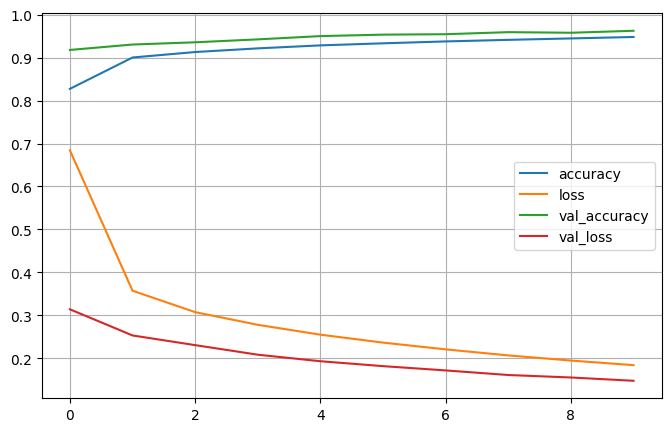

In [8]:
# plot
pd.DataFrame(history.history).plot(figsize=(8,5), grid=True)
plt.show()

## Part B: Convolutional Neural Network


In [9]:
# importing
from sklearn.metrics import ConfusionMatrixDisplay

In [10]:
fashon_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [11]:
# used expand_dims because the fashion dataset did not have the right dimensions and Conv2D takes in 4 dimensions 
X_train_cnn = np.expand_dims(X_train, -1)
X_test_cnn = np.expand_dims(X_test, -1)
X_valid_cnn = np.expand_dims(X_valid, -1)
y_valid_cnn = np.expand_dims(y_valid, -1)

In [24]:
# bulding CNN model
cnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=([28,28,1])),
    tf.keras.layers.Conv2D(filters=32, kernel_size=7),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120, activation="relu"), 
    tf.keras.layers.Dense(10, activation= "softmax")]
)

In [25]:
# compiling and fitting the model
cnn_model.compile(loss="sparse_categorical_crossentropy", optimizer = "nadam", metrics=["accuracy"])
cnn_model.fit(X_train_cnn, y_train, epochs=4, validation_data=(X_valid_cnn, y_valid))

Epoch 1/4
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9501 - loss: 0.1680 - val_accuracy: 0.9812 - val_loss: 0.0677
Epoch 2/4
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9805 - loss: 0.0619 - val_accuracy: 0.9804 - val_loss: 0.0661
Epoch 3/4
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9879 - loss: 0.0394 - val_accuracy: 0.9862 - val_loss: 0.0556
Epoch 4/4
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9900 - loss: 0.0308 - val_accuracy: 0.9842 - val_loss: 0.0646


In [26]:
# Evaluate
cnn_model.evaluate(X_test_cnn, y_test)
y_pred_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn.shape
y_pred_new = np.argmax(y_pred_cnn, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step - accuracy: 0.9837 - loss: 0.0580
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step


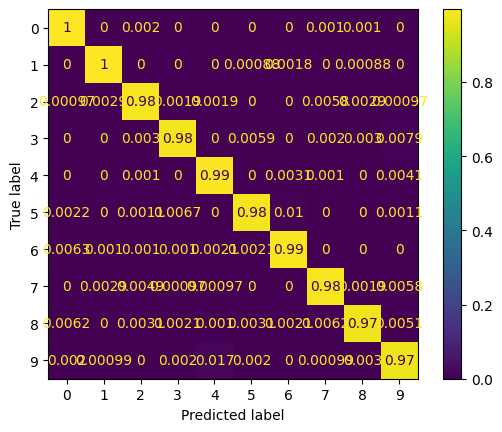

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_new, normalize="true")
plt.show()

## Part C: Experiment with Recurrent Neural Network

In [28]:
# importing libarires
from keras.datasets import imdb

In [29]:
# using 5000 as the amount
(X_train, y_train), (X_test, y_test)= imdb.load_data(num_words=5000)

/Users/luislopezmartinez/.venv/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [30]:
word_index = imdb.get_word_index()

In [31]:
max_len = 250
X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train, max_len)
X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test, max_len)
len(X_train[1])

250

In [32]:
# settin vocab size for the amount of unique words, and batch size for the how many reveiws modle will look at at one time. 
vocab_size = 5000
batch_size=200


In [33]:
# trying to predict the sentiment we choose the sigmoid because we can classify  positive and negative reviews if a value is more than
# 0.5 then its good review if its less than its a bad review
rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,)),
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 32)       │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,369 (649.88 KB)

 Trainable params: 166,369 (649.88 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
rnn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["acc"])
history = rnn_model.fit(X_train, y_train, epochs=3, batch_size=batch_size)

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - acc: 0.7066 - loss: 0.5367
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - acc: 0.8676 - loss: 0.3190
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - acc: 0.9012 - loss: 0.2530


In [35]:
results = rnn_model.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8616 - loss: 0.3389


In [36]:
# looking through every review and if a review is closer to 1 its a positive review if its closer to 0 it's a negative review.
rnn_model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


array([[0.1391923 ],
       [0.9748164 ],
       [0.8859461 ],
       ...,
       [0.07065113],
       [0.27576622],
       [0.9702671 ]], shape=(25000, 1), dtype=float32)